# Fuctional API

# Functional API code workflow
```mermaid
flowchart TD
    A[Initialize LLMs / Tools / APIs]
    B[Define Tasks using @task]
    C[Orchestrate Tasks using @entrypoint]
    D[Run Workflow using invoke/stream]

    A --> B
    B --> C
    C --> D
```

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

In [2]:
hf_token=os.getenv("HF_TOKEN")

In [10]:
from langgraph.func import task,entrypoint

In [7]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="conversational",
    huggingfacehub_api_token=hf_token,
    max_new_tokens=200,
    temperature=0.7
)

llm = ChatHuggingFace(llm=llm)

In [8]:
@task
def call_llm1(topic:str):
    """First LLM call to generate initial joke"""
    msg=llm.invoke(f"Write a joke about {topic}")
    return msg.content

@task
def call_llm2(topic:str):
    """Second LLM call to generate story"""
    msg=llm.invoke(f"Write a story about {topic}")
    return msg.content

@task
def call_llm3(topic:str):
    """Third LLM call to generate poem"""
    msg=llm.invoke(f"Write a poem about topic{topic}")
    return msg.content

@task 
def aggregator(topic,joke,story,poem):
    """Combine the joke,poem and story into a single output"""

    combined=f"Here is a story, joke and poem about {topic}!\n\n"
    combined+=f"Story: \n{story}\n\n"
    combined+=f"Joke : \n{joke}\n\n"
    combined+=f"Poem: \n{poem}"
    return combined
    

In [11]:
# build workflow

@entrypoint()
def parallel_workflow(topic:str):
    joke=call_llm1(topic).result()
    story=call_llm2(topic).result()
    poem=call_llm3(topic).result()
    return aggregator(topic,joke,story,poem).result()

In [13]:
#invoke

stream=parallel_workflow.stream_events("cats",version="v3")

C:\Users\INDIA\AppData\Roaming\Python\Python313\site-packages\langgraph\pregel\main.py:3723: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
C:\Users\INDIA\AppData\Roaming\Python\Python313\site-packages\langgraph\pregel\main.py:3573: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


In [14]:
for snapshot in stream.values:
    print(snapshot)
    print("\n")

Here is a story, joke and poem about cats!

Story: 
[{'type': 'text', 'text': 'Once upon a time, in a cozy little town nestled between rolling hills and a whispering forest, there lived a group of cats who were known for their peculiar and magical abilities. Among them was a particularly unique feline named Whisker, a tabby with silver streaks in his fur, who was the only cat in the town blessed with the power of understanding human speech.\n\nWhisker lived in a charming, old-fashioned house with a large, welcoming front porch. The house was filled with soft cushions, colorful toys, and a fireplace that seemed to keep the whole house warm, even on the coldest nights. Whisker was not just a cat; he was the protector and advisor to the inhabitants of the town, a guardian whose wisdom and kindness were unmatched.\n\nIn the town, there was a legend about a disappearing cat. Every year, for as long as anyone could remember, a cat would suddenly vanish, leaving behind only a note that read, 

# Graph API


```mermaid
flowchart TD
    A[Define State Schema]
    B[Create Nodes]
    C[Create Graph]
    D[Add Nodes]
    E[Add Edges]
    F[Compile Graph]
    G[Invoke or Stream]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
```

In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display


In [16]:
#graph state
class State(TypedDict):
    topic:str
    joke:str
    story:str
    poem:str
    combined_output:str

In [23]:
#nodes

def call_llm1(state:State):
    """First LLM call to generate initial joke"""
    msg=llm.invoke(f"Write  a joke about {state['topic']}")
    return {"joke":msg.content}

def call_llm2(state:State):
    """Second LLM call to generate story"""
    msg=llm.invoke(f"Write a story about {state['topic']}")
    return {"story":msg.content}

def call_llm3(state:State):
    """third LLM call to generate poem"""
    msg=llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem":msg.content}

def aggregator(state:State):
    """Combine the joke,poem and story into a single output"""

    combined=f"Here is a story, joke and poem about {state['topic']}!\n\n"
    combined+=f"Story: \n{state['story']}\n\n"
    combined+=f"Joke : \n{state['joke']}\n\n"
    combined+=f"Poem: \n{state['poem']}"
    return {"combined_output":combined}

In [24]:
#build workflow

parallel_builder=StateGraph(State)

#add nodes

parallel_builder.add_node("call_llm1",call_llm1)
parallel_builder.add_node("call_llm2",call_llm2)
parallel_builder.add_node("call_llm3",call_llm3)
parallel_builder.add_node("aggregator",aggregator)

In [25]:
# add edges


parallel_builder.add_edge(START,'call_llm1')
parallel_builder.add_edge(START,'call_llm2')
parallel_builder.add_edge(START,'call_llm3')
parallel_builder.add_edge("call_llm1","aggregator")
parallel_builder.add_edge("call_llm2","aggregator")
parallel_builder.add_edge("call_llm3","aggregator")
parallel_builder.add_edge("aggregator",END)

parallel_workflow=parallel_builder.compile()

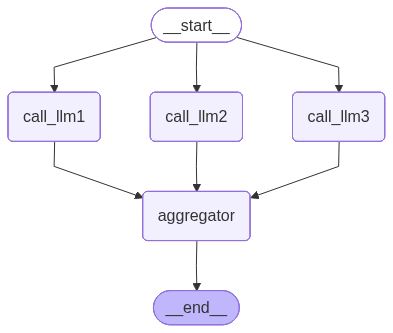

In [26]:
#show workflow

display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [27]:
#invoke

state=parallel_workflow.invoke({'topic':'cats'})
print(state['combined_output'])

Here is a story, joke and poem about cats!

Story: 
Once upon a time, in the small, picturesque village of Whiskerwood, there lived a family of cats known as the Whiskerwings. The Whiskerwings were a unique clan, each with their own distinct pattern and color, much like the leaves of the old oak tree that stood at the heart of the village.

The matriarch of the Whiskerwings was a majestic calico named Furryfoot, who was known for her wisdom and fairness. She ruled over her children with a gentle paw, ensuring that all the cats in Whiskerwood lived harmoniously. Her three kittens were the youngest members of the family: Ripple, a sleek gray tabby with a faint water pattern; Tangle, a mixed breed with a coat that shimmered like spun silver; and Paws, a little black cat with a heart as big as her head.

One sunny morning, as the dew was still glistening on the grass, a strange cat appeared

Joke : 
Why did the cat join the book club? Because she wanted to purrivate her opinions on literat